Strategi yang dibandingkan:

1. **Equally Weighted (EW)** — Portofolio naif 1/N, bobot seragam untuk semua aset.
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional (minimasi varians).
3. **Glasso Markowitz (GM)** — Markowitz dengan regularisasi *Graphical Lasso* pada kovarians.
4. **Network Markowitz (NW)** — RMT + MST + penalti sentralitas eigenvector (γ).
   * **NW (γ=0)** — Tanpa penalti jaringan (baseline NW).
   * **NW (γ=1.0)** — Penalti jaringan tetap γ = 1.0.
5. **NW Bayesian (VAR)** — Bayesian Optimization simultan (W, γ); objetivo: **minimasi varians**.
6. **NW Bayesian (Sharpe)** — Bayesian Optimization simultan (W, γ); objetivo: **maksimasi Sharpe Ratio**.

> **Catatan Bayesian:** Window W ∈ [20, 120 hari] dan Gamma γ ∈ [0.0, 2.0] dicari otomatis
> menggunakan Gaussian Process (scikit-optimize). Setelah backtesting, parameter optimal
> setiap periode divisualisasikan di sel *Rekapitulasi Parameter Optimal Bayesian*.


---
## Sel 1 — Persiapan Library

Mengimpor semua library yang diperlukan untuk analisis jaringan, optimasi portofolio, dan visualisasi.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada dataset return harian untuk **10 aset kripto utama** dalam periode **14 September 2017 – 17 Oktober 2019**.

In [64]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


---
## Sel 3 — Statistik Ringkasan (Summary Statistics)

Tabel statistik deskriptif mencakup Mean, Standar Deviasi, Kurtosis, dan Skewness untuk setiap aset kripto (mereplikasi **Tabel 1** pada paper acuan).

In [65]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


**Analisis Tabel 1:** Data menunjukkan bahwa sebagian besar aset kripto memiliki nilai *kurtosis* yang sangat tinggi (di atas 3), terutama TRX (22.18) dan XRP (18.90). Hal ini mengonfirmasi sifat *heavy-tailed* dari distribusi return kripto, di mana risiko ekstrem lebih sering terjadi dibandingkan distribusi normal. Nilai *Mean* yang mendekati nol mencerminkan efisiensi pasar secara rata-rata, namun volatilitas (*Std*) yang tinggi (rata-rata > 4%) menunjukkan risiko investasi yang sangat besar.

---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi **100** pada tanggal **7 Januari 2018**.

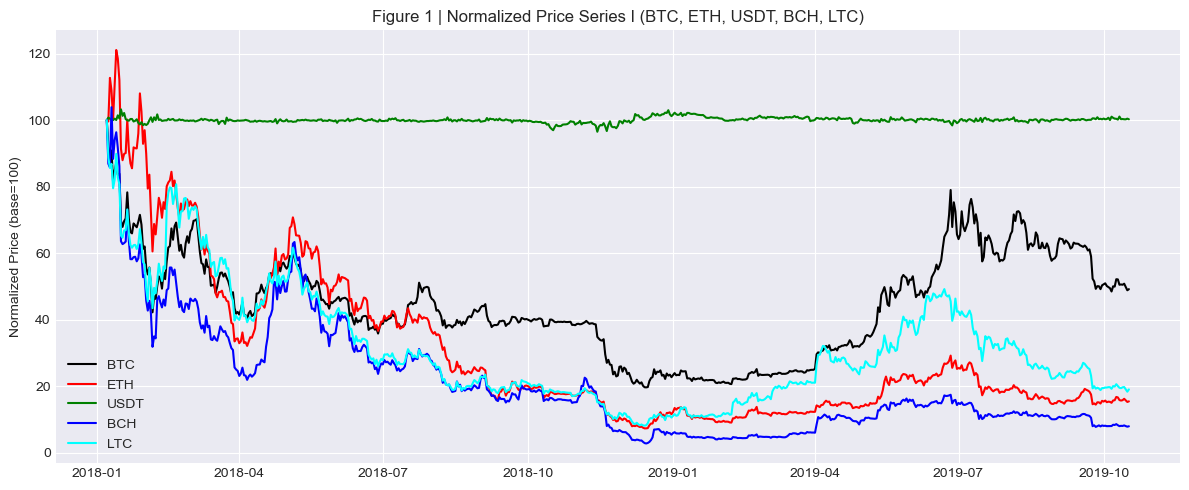

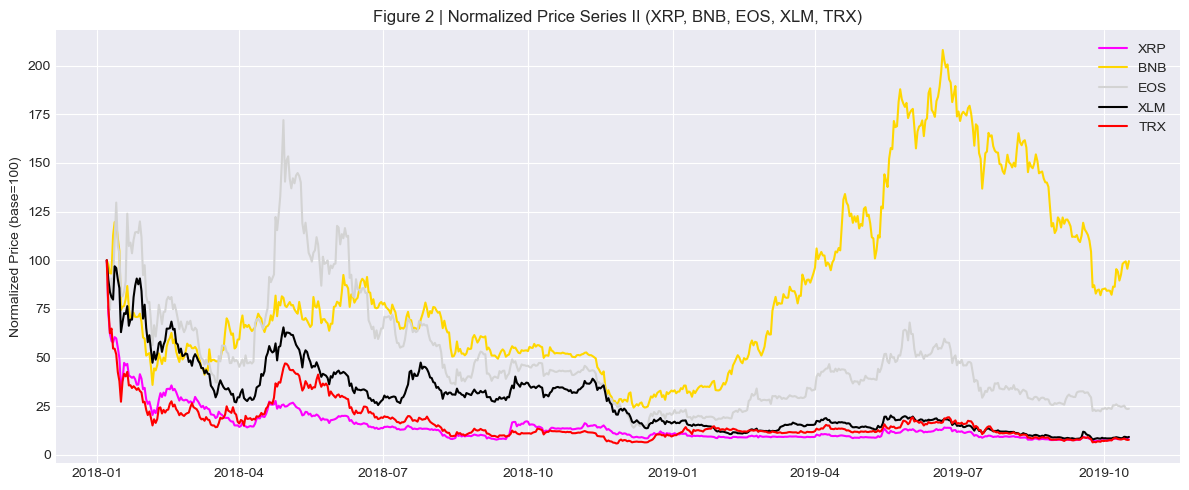

In [66]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 dari paper acuan, menunjukkan struktur jaringan aset kripto selama dua periode berbeda:
- **Figure 3**: Periode gelembung spekulatif (Sep 2017 – Jan 2018)
- **Figure 4**: Periode stabil (Jun 2019 – Okt 2019)

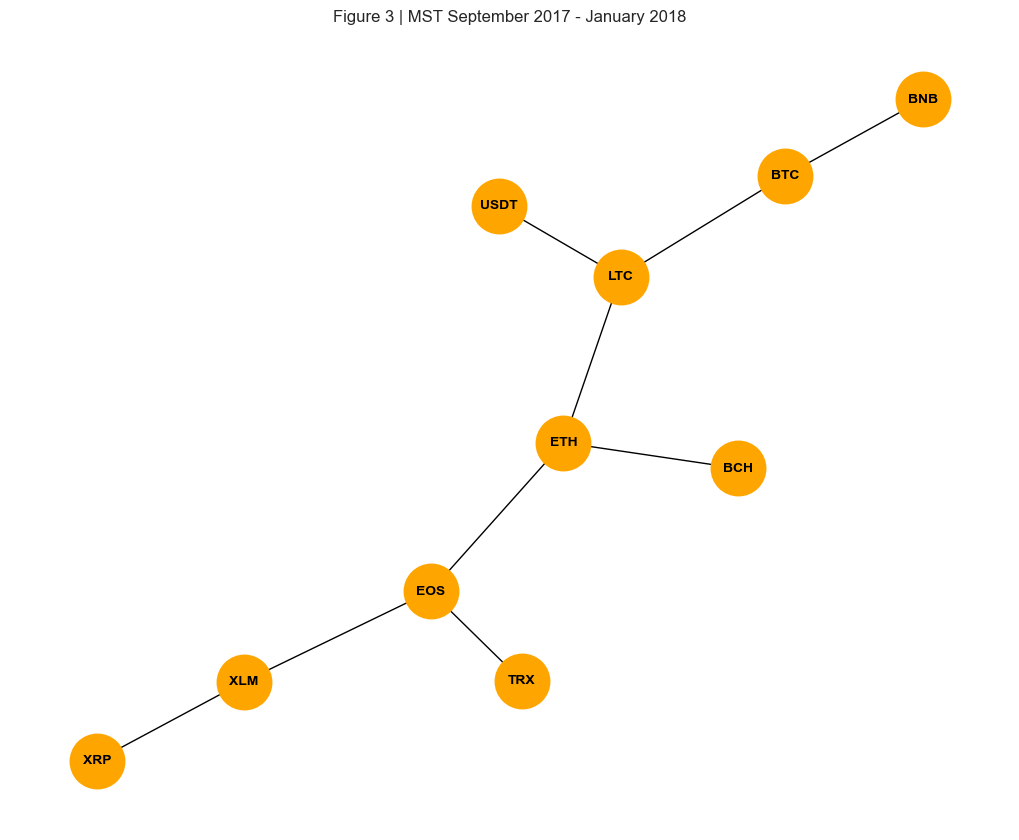

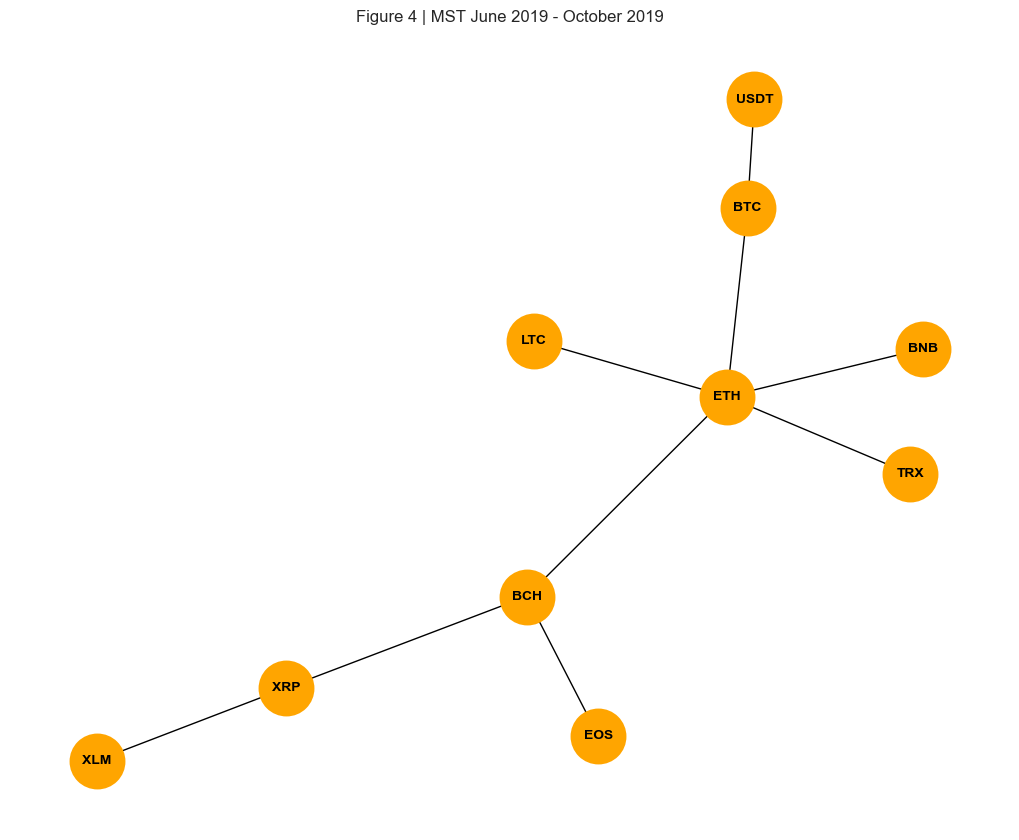

In [67]:
# --- Figure 3 | MST Speculative Bubble Period ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

# --- Figure 4 | MST Stable Period ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

**Analisis Figure 3 & 4 (Evolusi Topologi Minimum Spanning Tree):**

Perbandingan antara *Figure 3* (Fase *Speculative Bubble*, Sep 2017 – Jan 2018) dan *Figure 4* (Fase *Stable*, Jun 2019 – Okt 2019) memperlihatkan perubahan signifikan dalam struktur ketergantungan antar aset kripto:

1. **Fase Speculative Bubble (Figure 3):** Struktur MST cenderung lebih memanjang dan berantai (*chain-like topology*). Aset-aset terhubung secara linier dengan **ETH** dan **LTC** berperan sebagai jembatan (*bridge*) antar klaster:
   - **LTC** menghubungkan klaster atas (BTC, BNB, USDT) dengan klaster bawah melalui ETH.
   - **ETH** menjadi penghubung utama antara klaster LTC, EOS, dan BCH.
   - **EOS** membentuk sub-klaster dengan XLM, TRX, dan XRP.
   - Tidak ada satu *super hub* yang mendominasi; sentralitas terdistribusi merata. Hal ini mengindikasikan bahwa selama periode euforia, setiap altcoin bergerak dengan dinamika spekulatif masing-masing.

2. **Fase Stable (Figure 4):** Struktur jaringan berubah drastis menjadi sangat terpusat (*star-like topology*). **ETH** muncul sebagai *super hub* yang menghubungkan langsung hampir semua aset. Pergerakan aset menjadi lebih seragam (*highly coupled*) sehingga risiko sistemik terkonsentrasi di pusat jaringan.

Perubahan dari topologi berantai ke bintang inilah yang ditangkap oleh **sentralitas vektor eigen** (*eigenvector centrality*) dalam fungsi penalti Network Markowitz (NW), memungkinkannya meminimalkan eksposur pada *hub* yang rentan kolaps sistemik.

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi fungsi-fungsi pembantu yang digunakan oleh semua strategi:
- **RMT Filter** — Penyaringan noise pada matriks korelasi menggunakan Random Matrix Theory (batas Marchenko-Pastur λ+).
- **MST Builder** — Konstruksi matriks jarak dari korelasi: $d_{ij} = \sqrt{2(1 - \rho_{ij})}$.
- **Eigenvector Centrality** — Mengukur sentralitas aset dalam jaringan.
- **Metrik Risiko** — VaR, Rachev Ratio, Maximum Drawdown.


In [68]:
def apply_rmt_filter(returns_data):
    """
    Menerapkan filter Random Matrix Theory (RMT) pada matriks korelasi aset.
    
    Fungsi ini bertujuan untuk memisahkan "sinyal" (informasi pasar yang sebenarnya) 
    dari "noise" (fluktuasi acak) dalam matriks korelasi imbal hasil (returns) aset. 
    Metode ini sangat berguna dalam optimasi portofolio untuk mencegah terjadinya over-fitting 
    terhadap noise historis, sehingga estimasi matriks korelasi yang dihasilkan menjadi 
    lebih stabil dan dapat diandalkan (robust).

    Alur Narasi Proses:
    1. Persiapan Data: Memastikan data berformat matriks numpy agar siap diolah.
    2. Korelasi Empiris: Membentuk matriks korelasi Pearson standar dari data imbal hasil.
    3. Dekomposisi Eigen: Memecah matriks korelasi menjadi nilai eigen dan vektor eigen untuk 
       melihat varians dari komponen utama.
    4. Thresholding Marchenko-Pastur: Menghitung ambang batas (lambda_plus) acak 
       berdasarkan teori matriks acak.
    5. Penyaringan (Filtering): Memilah mana nilai eigen yang "nyata" (sinyal) 
       dan mana yang "acak" (noise). Noise kemudian dihilangkan (di-nol-kan).
    6. Rekonstruksi: Membangun kembali matriks korelasi baru yang sudah dibersihkan dari noise.

    Parameters:
    -----------
    returns_data : pandas.DataFrame atau numpy.ndarray
        Data deret waktu imbal hasil (returns) dari berbagai aset. 
        Asumsi format: Baris (T observasi) x Kolom (N aset).

    Returns:
    --------
    C_filtered : numpy.ndarray
        Matriks korelasi baru (N x N) yang telah disaring dan dibersihkan dari noise.
    """
    
    # =====================================================================
    # TAHAP 1: PERSIAPAN DAN EKSTRAKSI DATA
    # =====================================================================
    # Mengkonversi Pandas DataFrame (jika ada) menjadi Numpy Array mentah. 
    # Langkah ini diperlukan untuk optimasi komputasi aljabar linear ke depannya.
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
        
    # Ekstraksi dua dimensi penting penyusun sistem:
    # T = Jumlah total observasi data runtut waktu (panjang waktu)
    # N = Jumlah komponen cross-sectional (jumlah aset)
    T, N = data.shape
    
    # Q merepresentasikan rasio aspek dari sistem informasi kita.
    # Nilai ini adalah kunci utama untuk kalkulasi batas limit teoritis nanti.
    Q = T / N
    
    # =====================================================================
    # TAHAP 2: PEMBENTUKAN MATRIKS KORELASI EMPIRIS
    # =====================================================================
    # Menghitung korelasi Pearson konvensional (C).
    # Kita menggunakan `.T` (transpose) karena np.corrcoef mengasumsikan 
    # variabel direpresentasikan oleh baris, sedangkan konvensi kita aset ada di kolom.
    C = np.corrcoef(data.T)

    # =====================================================================
    # TAHAP 3: DEKOMPOSISI STRUKTUR MATRIKS (EIGENDECOMPOSITION)
    # =====================================================================
    # Fungsi eigh dioptimalkan khusus untuk matriks simetris seperti matriks korelasi,
    # menghasilkan pemetaan dasar berupa bobot (eigenvalues) dan arah (eigenvectors).
    eigenvalues, eigenvectors = eigh(C)
    
    # Secara default eigh mengurutkan dari terkecil hingga terbesar (ascending).
    # Agar lebih intuitif dalam membaca faktor terpenting, kita balik susunannya (descending)
    # dari spektrum/pengaruh pasar terbesar ke terkecil.
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    # =====================================================================
    # TAHAP 4: PENETAPAN AMBANG BATAS MARCHENKO-PASTUR
    # =====================================================================
    # Mencari titik limit atas (lambda_plus). Apapun nilai eigen yang berada 
    # di bawah ambang batas ini secara teoritis dianggap hanya merupakan produk dari 
    # varians yang sepenuhnya acak (pure random noise), bukan faktor pasar fundamental.
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    
    # Mengidentifikasi spektrum yang secara statistik signifikan.
    # Evaluasi ini menghasilkan array berbentuk boolean (True = Sinyal, False = Noise).
    significant_mask = eigenvalues > lambda_plus

    # =====================================================================
    # TAHAP 5 & 6: PENYARINGAN (FILTERING) DAN REKONSTRUKSI
    # =====================================================================
    # Semua nilai eigen yang dicap sebagai 'False' (noise) diganti menjadi 0.
    # Sementara nilai eigen yang signifikan (True) dibiarkan murni apa adanya.
    # Kemudian diubah menjadi matriks diagonal (Lambda_filtered).
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    
    # Terakhir, matriks korelasi "bersih" dihidupkan/disintesis kembali 
    # tanpa memuat elemen noise dengan mengalikan matriks eigen, diagonal lambda bersih,
    # dan transpose (invers) dari matriks eigen.
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered


def build_mst(correlation_matrix):
    """
    Menghitung matriks jarak (Distance Matrix) dari matriks korelasi sebagai
    tahap pra-pemrosesan untuk pembentukan Minimum Spanning Tree (MST).
    
    Transformasi ini menggunakan metrik jarak Mantegna (1999) yang secara
    umum didefinisikan sebagai d_ij = sqrt(2 * (1 - rho_ij)). Metrik ini
    mentransformasikan korelasi (Pearson) ke dalam ruang Euclidean.
    
    Matematika Transformasi:
    1. Jika rho =  1 (Korelasi Positif Sempurna), maka d = 0 (Jarak terdekat).
    2. Jika rho =  0 (Tidak Ada Korelasi),       maka d = sqrt(2) ≈ 1.41.
    3. Jika rho = -1 (Korelasi Negatif Sempurna), maka d = 2 (Jarak terjauh).
    
    Parameters:
    -----------
    correlation_matrix : numpy.ndarray
        Matriks korelasi antar aset berukuran (N x N). Matriks ini harus
        bersifat simetris dan memiliki nilai diagonal bernilai 1.0.
        
    Returns:
    --------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N) yang memenuhi sifat-sifat metrik:
        - Non-negatif: d_ij >= 0
        - Identitas: d_ii = 0
        - Simetris: d_ij = d_ji
        - Ketidaksamaan Segitiga: d_ij <= d_ik + d_kj
    """
    
    # 1. Menghitung Matriks Jarak
    # Rumus ini mengubah koefisien korelasi rho_ij yang berada pada rentang [-1, 1]
    # menjadi nilai jarak d_ij pada rentang [0, 2].
    # Operasi diperlakukan secara elemen-wise pada seluruh array/matriks.
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    
    # 2. Penanganan Floating Point Error pada Diagonal
    # Secara teoritis, korelasi aset dengan dirinya sendiri (rho_ii) adalah 1.0,
    # yang menghasilkan jarak sqrt(2 - 2*1) = 0.
    # Namun, karena keterbatasan presisi komputer (floating point), hasilnya
    # terkadang menjadi nilai sangat kecil (misal 1e-16).
    # Mengisi diagonal secara eksplisit dengan 0 menjamin konsistensi metrik.
    np.fill_diagonal(distance_matrix, 0)
    
    # Tips untuk Stabilitas Numerik:
    # Jika matriks korelasi mengandung noise, diskalakan atau diklip untuk 
    # memastikan tidak ada nilai di bawah 0 sebelum diakar kuadrat:
    # distance_matrix = np.sqrt(np.maximum(0, 2 - 2 * correlation_matrix))
    
    return distance_matrix



def compute_eigenvector_centrality(distance_matrix):
    """
    Menghitung skor Eigenvector Centrality dari matriks jarak (Distance Matrix).
    
    Eigenvector centrality memberikan ukuran seberapa 'penting' suatu aset 
    di dalam jaringan. Berbeda dengan degree centrality (yang hanya menghitung 
    jumlah koneksi), eigenvector centrality mempertimbangkan kualitas koneksi; 
    suatu aset dianggap penting jika ia terhubung dengan aset-aset lain yang 
    juga memiliki kepentingan tinggi.
    
    Dalam studi portofolio (Network Markowitz), metrik ini digunakan untuk 
    mendeteksi aset sistemik atau aset yang berada di pusat kluster risiko.
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N). Nilai kecil pada matriks ini 
        menunjukkan korelasi yang kuat antar aset.
    Returns:
    --------
    centrality : numpy.ndarray
        Vektor berukuran (N,) berisi skor centrality yang dinormalisasi.
        Nilai yang lebih tinggi menunjukkan aset yang lebih sentral di pasar.
    """
    
    # 1. Transformasi Jarak menjadi Matriks Adjacency (Kedekatan)
    # Eigenvector centrality umumnya dihitung pada matriks kesamaan (similarity).
    # Karena input adalah jarak (d), kita melakukan inversi (1/d).
    # Konstanta 1e-8 (epsilon) ditambahkan untuk mencegah 'DivisionByZero' pada diagonal.
    adjacency = 1 / (distance_matrix + 1e-8)
    
    # 2. Menghilangkan Self-loops
    # Mengatur nilai diagonal menjadi 0 agar algoritma tidak menghitung 
    # koneksi aset dengan dirinya sendiri sebagai bobot sentralitas.
    np.fill_diagonal(adjacency, 0)
    
    # 3. Menghitung Eigenvalues dan Eigenvectors
    # eigh digunakan alih-alih eig karena matriks adjacency kita bersifat simetris.
    # Ini lebih efisien secara komputasi dan memberikan hasil yang lebih stabil.
    # eigh mengembalikan eigenvalue dalam urutan menaik (kecil ke besar).
    eigenvalues, eigenvectors = eigh(adjacency)
    
    # 4. Mengambil Principal Eigenvector
    # Berdasarkan Teorema Perron-Frobenius, faktor sentralitas bersesuaian dengan
    # eigenvector yang memiliki eigenvalue terbesar (kolom terakhir pada output eigh).
    # np.abs digunakan untuk memastikan semua skor bernilai positif.
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    
    # 5. Normalisasi L1
    # Membagi setiap skor dengan total jumlah skor agar total sum = 1.
    # Ini merepresentasikan faksi atau bobot relatif kepentingan tiap aset di jaringan.
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality


def calculate_var(returns, confidence=0.95):
    """
    Menghitung Value at Risk (VaR) menggunakan metode Simulasi Historis.
    
    Value at Risk (VaR) adalah metrik risiko statistik yang mengestimasi 
    potensi kerugian maksimum dalam portofolio pada tingkat kepercayaan 
    tertentu dalam periode waktu tertentu.
    
    Contoh Interpretasi:
    Jika VaR(95%) bernilai -0.02, artinya kita memiliki keyakinan 95% bahwa 
    kerugian portofolio tidak akan melebihi 2% dalam satu hari kerja, 
    atau terdapat peluang 5% bahwa kerugian akan melampaul 2%.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (return) dari aset atau portofolio.
    confidence : float, default 0.95
        Tingkat kepercayaan (confidence level). 0.95 berarti kita fokus 
        pada 5% kemungkinan terburuk (significance level alpha = 0.05).

    Returns:
    --------
    var_value : float
        Nilai batas bawah (threshold) imbal hasil pada persentil yang ditentukan.
    """
    
    # 1. Menghitung Nilai Alpha (Significance Level)
    # Alpha merepresentasikan probabilitas terjadinya kerugian ekstrem di ekor distribusi.
    # Untuk confidence 0.95 (95%), alpha adalah 0.05 (5%).
    alpha = 1 - confidence
    
    # 2. Mengambil Titik Potong pada Distribusi Historis
    # Menggunakan metode non-parametrik (Simulasi Historis) dengan mencari 
    # persentil terbawah dari data return asli tanpa mengasumsikan distribusi normal.
    # np.percentile mengonversi alpha (0.05) menjadi indeks persentil (5%).
    var_value = np.percentile(returns, alpha * 100)
    
    # --- CATATAN TEKNIS & KRITIS ---
    # a) Nilai Output: var_value biasanya bernilai negatif dalam data return, 
    #    yang secara intuitif merepresentasikan kerugian.
    # b) Kelemahan Utama: VaR hanya menunjukkan 'Ambang Batas' kerugian, 
    #    tetapi tidak memberitahu kita sebesar apa kerugian jika ambang tersebut 
    #    terlampaui (masalah ini diselesaikan oleh metrik CVaR/Expected Shortfall).
    # c) Asumsi: Metode ini mengasumsikan struktur risiko masa lalu akan 
    #    terulang di masa depan (stationarity of risk).
    
    return var_value


def calculate_rachev_ratio(returns, alpha=0.10):
    """
    Menghitung Rachev Ratio untuk mengukur efisiensi imbal hasil pada ekor distribusi.
    
    Rachev Ratio mengukur perbandingan antara potensi keuntungan ekstrem (reward) 
    terhadap potensi kerugian ekstrem (risk). Berbeda dengan Sharpe Ratio, 
    metrik ini sangat efektif untuk aset dengan distribusi non-normal (fat-tails) 
    dan asimetris (skewed), yang umum ditemukan di pasar cryptocurrency.

    Formula:
    Rachev Ratio = CVaR(alpha, upper) / CVaR(alpha, lower)

    Interpretasi:
    Nilai > 1 menunjukkan bahwa potensi keuntungan di ekor kanan distribusi 
    lebih besar dibandingkan potensi kerugian di ekor kiri pada tingkat kepercayaan 1-alpha.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (returns) strategi.
    alpha : float, default 0.10
        Tingkat signifikansi (probability tail). Misal 0.10 berarti kita 
        menganalisis 10% kejadian paling ekstrem (terbaik vs terburuk).

    Returns:
    --------
    rachev_ratio : float
        Rasio antara CVaR Atas per CVaR Bawah.
    """
    
    # 1. Menghitung Batas Ambang (Value at Risk - VaR)
    # threshold_upper: Batas bawah untuk 10% keuntungan terbaik (persentil 90).
    # threshold_lower: Batas atas untuk 10% kerugian terburuk (persentil 10).
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    
    # 2. Menghitung Conditional Value at Risk (CVaR) atau Expected Shortfall
    # cvar_upper: Menghitung rata-rata dari semua return yang melampaui ambang batas atas.
    # Ini merepresentasikan rata-rata keuntungan pada kondisi pasar 'bullish' ekstrem.
    cvar_upper = returns[returns >= threshold_upper].mean()
    
    # cvar_lower: Menghitung rata-rata dari semua return yang di bawah ambang batas bawah.
    # Menggunakan 'abs' karena penyebut dalam rasio risiko harus bernilai positif 
    # untuk interpretasi yang benar. Ini merepresentasikan rata-rata 'crash' pasar.
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    # 3. Finalisasi Rasio
    # Dilakukan pengecekan agar tidak terjadi error 'division by zero' jika 
    # data return tidak memiliki variansi (sangat jarang terjadi pada data real).
    if cvar_lower > 0:
        rachev_ratio = cvar_upper / cvar_lower
    else:
        rachev_ratio = 0
        
    # --- CATATAN PEMBAHASAN TESIS ---
    # Gunakan Rachev Ratio untuk berargumen bahwa strategi Network Markowitz 
    # Anda tidak hanya menurunkan risiko, tapi juga mempertahankan 
    # 'upside potential' pada saat terjadi pergerakan harga yang menguntungkan.
    
    return rachev_ratio

def calculate_max_drawdown(cumulative_returns):
    """
    Menghitung Maximum Drawdown (MDD) dari deret imbal hasil kumulatif.
    
    Maximum Drawdown mengukur penurunan persentase terbesar yang diamati dari 
    titik puncak (peak) ke titik terendah (trough) dalam suatu periode waktu, 
    sebelum titik puncak baru terbentuk. Ini mencerminkan risiko kerugian 
    ekstrem yang mungkin dialami investor.

    Interpretasi:
    - Jika MDD = -0.25, berarti strategi tersebut pernah mengalami penurunan 
      nilai sebesar 25% dari titik tertingginya.
    - Semakin mendekati 0, semakin baik ketahanan strategi dalam menjaga modal.

    Parameters:
    -----------
    cumulative_returns : numpy.ndarray | pandas.Series
        Deret imbal hasil kumulatif (kurva ekuitas). 
        Pastikan input adalah data kumulatif (misal: 1, 1.05, 1.02, 1.08).

    Returns:
    --------
    max_drawdown : float
        Nilai penurunan maksimum dalam bentuk desimal (selalu <= 0).
    """

    # 1. Menghitung Running Maximum (Titik Puncak Berjalan)
    # Fungsi ini membuat deret baru yang mencatat nilai tertinggi yang pernah 
    # dicapai di setiap titik waktu sejak awal periode. 
    # Ini digunakan sebagai 'garis referensi' puncak tertinggi.
    running_max = np.maximum.accumulate(cumulative_returns)
    
    # 2. Menghitung Nilai Drawdown
    # Drawdown dihitung sebagai persentase selisih antara nilai saat ini 
    # dengan nilai puncak tertinggi sebelumnya.
    # Formula: (Nilai Saat Ini - Puncak Tertinggi) / Puncak Tertinggi
    # Jika hasilnya 0, berarti portofolio sedang berada di titik rekor baru.
    drawdown = (cumulative_returns - running_max) / running_max
    
    # 3. Mencari Drawdown Terburuk (Maximum Drawdown)
    # Mengambil nilai minimum (angka negatif paling besar) dari seluruh periode.
    # Inilah titik 'penderitaan' terbesar bagi seorang investor.
    max_drawdown = drawdown.min()

    # --- KONTEKS ANALISIS TESIS ---
    # MDD membantu Anda membuktikan apakah strategi 'Network Markowitz' 
    # lebih tahan banting terhadap guncangan pasar (market crashes) 
    # dibandingkan strategi klasis dengan melihat seberapa dalam 
    # penurunan nilainya saat terjadi krisis di pasar kripto.
    
    return max_drawdown

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Melakukan seleksi aset untuk diversifikasi menggunakan algoritma 
    Maximum Independent Set (MIS) berbasis teori jaringan.
    
    Konsep Dasar Jaringan:
    1. Node (Simpul): Mewakili aset kripto dalam semesta portofolio.
    2. Edge (Sisi): Menghubungkan dua aset jika korelasi absolutnya melampaui 
       batas 'corr_threshold'. Sisi ini melambangkan 'redundansi' informasi risiko.
    3. Independent Set: Kumpulan aset yang TIDAK saling terhubung satu sama lain.
       Artinya, tidak ada aset dalam set ini yang memiliki korelasi tinggi.
    
    Tujuan Utama:
    Menemukan jumlah aset terbanyak yang memiliki tingkat ketergantungan (korelasi) 
    paling rendah satu sama lain demi memaksimalkan efek diversifikasi.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Window data historis return aset (T bare x N kolom).
    corr_threshold : float, default 0.4
        Parameter theta (θ). Ambang batas di mana korelasi dianggap 'terlalu kuat'.
        Semakin rendah nilainya, semakin sedikit aset yang terpilih (diversifikasi sangat ketat).
    Returns:
    --------
    selected_assets : list
        Daftar nama aset terverifikasi yang membentuk Independent Set terbesar.
    """
    
    # 1. Menghitung Matriks Korelasi Antar Aset
    corr_mat = returns_window.corr()
    
    # 2. Inisialisasi Graf NetworkX
    G = nx.Graph()
    
    # 3. Menyiapkan Daftar Aset
    # Diurutkan berdasarkan rata-rata return (opsional) untuk memberikan 
    # prioritas heuristik pada aset yang memiliki performa rata-rata baik.
    assets = list(returns_window.mean()
                    .sort_values(ascending=False).index)
    
    # Menambahkan seluruh aset sebagai simpul (node) awal dalam graf
    G.add_nodes_from(assets)
    
    # 4. Konstruksi Jaringan (Graph Building)
    # Iterasi melalui setiap pasangan unik aset (i, j)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            # Menggunakan nilai absolut korelasi (abs)
            # Karena korelasi negatif kuat maupun positif kuat menunjukkan 
            # adanya ketergantungan (dependency) antar aset.
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                # Jika korelasi > threshold, tarik garis (edge).
                # Garis ini menandakan bahwa kedua aset tersebut 'serupa' 
                # secara pergerakan harga dan tidak baik diambil bersama-sama.
                G.add_edge(a1, a2)
    
    # 5. Mencari Maximum Independent Set (MIS)
    # Algoritma ini mencari subset node terbesar di mana tidak ada korelasi 
    # kuat antar anggota di dalamnya.
    # Karena MIS adalah problem NP-Hard, kita menggunakan algoritma pendekatan 
    # (approximation) agar proses backtest berjalan efisien namun tetap akurat.
    selected_assets = list(nx.approximation.maximum_independent_set(G))
    
    # --- CATATAN UNTUK TESIS ---
    # Pendekatan ini secara proaktif membuang aset yang berada dalam satu 'kluster korelasi'.
    # Jika satu aset dalam kluster terkena krisis, diharapkan aset di Independent Set 
    # lain tidak terpengaruh, sehingga risiko sistemik dapat ditekan secara geografis jaringan.
    
    return selected_assets


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """
    Menyeleksi aset independen melalui jaringan graf yang telah difilter 
    menggunakan Random Matrix Theory (RMT).
    
    Keunggulan Metodologi RMT-Graph:
    1. Korelasi historis standar seringkali dipenuhi oleh 'noise' (gangguan) 
       akibat window data yang terbatas (fat-tails).
    2. RMT memisahkan eigenvalue korelasi menjadi dua bagian: 'noise' (yang 
       berada dalam bulk Marchenko-Pastur) dan 'signal' (eigenvalue yang keluar).
    3. Dengan menggunakan 'Filtered Correlation' (corr_f), sisi (edge) pada 
       graf hanya ditarik jika terdapat hubungan ekonomi yang benar-benar 
       signifikan (pure signal), bukan karena kebetulan statistik.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Dataframe imbal hasil aset (N x T).
    corr_threshold : float, default 0.4
        Ambang batas (theta) untuk menentukan apakah signal korelasi 
        cukup kuat untuk membentuk koneksi antar aset.
    Returns:
    --------
    selected_assets_rmt : list
        Kumpulan aset independen (Maximum Independent Set) hasil filter RMT.
    """
    
    # 1. Menentukan List Aset
    assets = returns_window.columns.tolist()
    
    # 2. Aplikasi Filter RMT (Penyaringan Noise)
    # Memanggil rutin 'apply_rmt_filter' untuk mendapatkan matriks korelasi bersih.
    # Langkah ini sangat krusial dalam tesis Anda untuk melenyapkan korelasi palsu.
    corr_f = apply_rmt_filter(returns_window)
    
    # 3. Membangun Struktur Graf
    G = nx.Graph()
    G.add_nodes_from(assets)
    
    # 4. Konstruksi Jaringan Berbasis Signal (Signal-Based Graph Building)
    # Loop melalui indeks baris (i) dan kolom (j) pada matriks korelasi RMT.
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            # i < j digunakan untuk menghindari penghitungan ganda (simetris) 
            # dan pengabaian diagonal (i=j) demi efisiensi komputasi.
            if i < j:
                # Menggunakan korelasi absolut yang sudah dibersihkan (|rho_filtered|).
                # Jika nilai signal korelasi > threshold (theta):
                if abs(corr_f[i, j]) > corr_threshold:
                    # Tarik garis (edge) yang menunjukkan redundansi antar aset.
                    G.add_edge(a1, a2)
    
    # 5. Algoritma Maximum Independent Set (MIS) dengan Data Terfilter
    # Mencari subset aset paling banyak yang tidak saling terhubung oleh signal korelasi.
    # Hasil dari tahap ini adalah daftar aset diversifikasi yang paling kokoh.
    selected_assets_rmt = list(nx.approximation.maximum_independent_set(G))
    
    # --- CATATAN PEMBAHASAN TESIS ---
    # Pendekatan ini adalah 'Double-Filtering':
    # - Filter 1 (RMT): Membersihkan Kebisingan Statistik.
    # - Filter 2 (Graph): Menghilangkan Redundansi Struktural.
    # Penggabungan ini meminimalisir kemungkinan terpilihnya aset yang hanya 
    # berkorelasi secara kebetulan selama jendela estimasi (estimation window).
    
    return selected_assets_rmt


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel 7 — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung dua metrik dinamis jaringan: **Max Link Distance** dan **Residuality**.

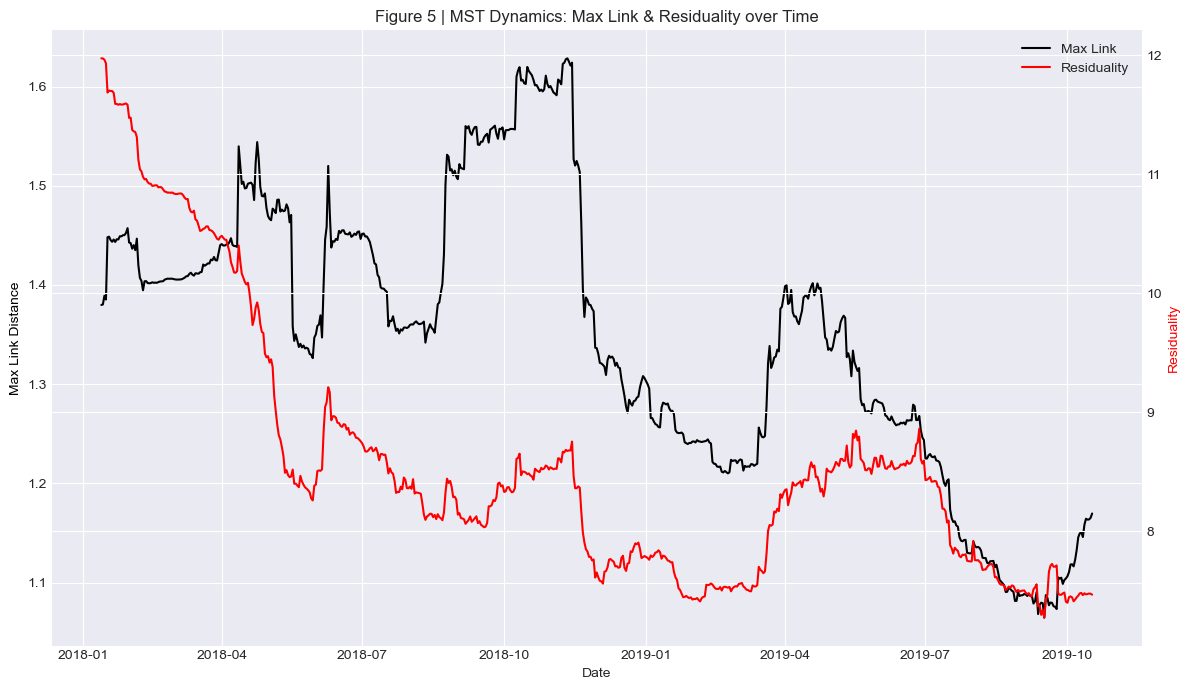

In [69]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dengan dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

**Analisis Figure 5 (Dinamika MST: Max Link Distance & Residuality):**

Grafik di atas menampilkan dua metrik dinamis jaringan yang dihitung secara *rolling window* sepanjang periode observasi:

1. **Max Link Distance** (garis hitam, sumbu kiri): Mengukur jarak maksimum antar node pada MST. Semakin tinggi nilainya, semakin ada pasangan aset yang bergerak sangat berbeda (*decoupled*) satu sama lain.
   - **Awal 2018 (Jan–Mar):** Max Link sangat tinggi (~1.4–1.6), menandakan fragmentasi jaringan selama *crash* pasca-bubble. Beberapa aset jatuh tajam sementara yang lain masih tertahan, menciptakan jarak antar node yang ekstrem.
   - **Mar–Sep 2018:** Terjadi lonjakan kembali ke ~1.6, mengindikasikan periode ketidakstabilan dan turbulensi pasar yang berulang.
   - **Akhir 2018 – Awal 2019:** Max Link turun drastis ke ~1.1, menandakan pasar *bear* yang stabil — semua aset jatuh bersama secara seragam.
   - **Apr–Jul 2019:** Lonjakan kembali ke ~1.4, bersamaan dengan *mini bull run* Bitcoin yang mendekople beberapa altcoin.
   - **Akhir 2019:** Kembali turun ke ~1.1, pasar stabil kembali.

2. **Residuality** (garis merah, sumbu kanan): Mengukur seberapa banyak informasi korelasi yang *tidak* tertangkap oleh MST. Residuality tinggi berarti struktur jaringan lebih kompleks dan MST saja kurang cukup merepresentasikan hubungan antar aset.
   - **Awal 2018:** Residuality sangat tinggi (~12), menunjukkan kompleksitas hubungan antar aset selama periode euforia dan crash.
   - **Tren menurun sepanjang 2018:** Residuality turun secara bertahap dari ~12 ke ~8, seiring pasar memasuki fase *bear* yang lebih sederhana secara struktural.
   - **2019:** Residuality stabil di kisaran 7.5–9, dengan sedikit kenaikan pada pertengahan tahun seiring *mini rally*.

**Korelasi antara kedua metrik:**
- Kedua metrik menunjukkan **tren menurun** yang serupa dari awal 2018 ke akhir 2019, mengkonfirmasi bahwa jaringan semakin *compact* dan tersentralisasi seiring waktu (konsisten dengan transformasi topologi dari *chain-like* ke *star-like* yang diamati pada Figure 3 & 4).
- Lonjakan simultan pada Max Link dan Residuality (misalnya April 2018, Oktober 2018, April 2019) menandakan periode **transisi regime pasar** — momen di mana struktur jaringan berubah secara signifikan.
- Implikasi untuk **NW Adaptis**: Variasi rolling window yang lebih pendek (30, 60 hari) diharapkan lebih responsif dalam menangkap transisi-transisi regime ini dibandingkan window standar 120 hari.

---
## Sel 8 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas Python yang mewarisi `PortfolioStrategy`.



In [70]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
    def get_weights(self, returns_data):
        raise NotImplementedError


# -- 1. Equally Weighted -----------------------------------------------------
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# -- 2. Classical Markowitz --------------------------------------------------
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


# -- 3. Glasso Markowitz -----------------------------------------------------
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


# -- 4. Network Markowitz ----------------------------------------------------
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


In [ ]:


class BayesianNW(NetworkMarkowitz):
    """
    Network Markowitz dengan Optimasi Bayesian Simultan untuk (W, γ).

    Mencari kombinasi optimal secara BERSAMAAN menggunakan Gaussian Process:
    - Parameter 1: Window (W) : integer [20 – 120 hari]
    - Parameter 2: Gamma  (γ) : float   [0.0 – 2.0]

    Setiap periode rebalancing, parameter optimal yang ditemukan langsung
    dicetak ke layar DAN disimpan ke param_history untuk analisis lanjutan.
    """

    def __init__(self, name="NW Bayesian (VAR)", window_size=120):
        # window_size=120 hanya nilai awal; nilai aktual ditentukan Bayesian
        super().__init__(name, gamma=1.0, window_size=window_size)
        self.param_history = []   # log: {date, window, gamma, score}

    # ------------------------------------------------------------------
    def _compute_nw_weights(self, data, gamma):
        """Hitung bobot NW dengan gamma tertentu pada data yang diberikan."""
        n_assets = data.shape[1]
        std = data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any():
            return np.ones(n_assets) / n_assets
        fd   = data.loc[:, valid_assets]
        mu   = fd.mean().values
        sig  = fd.std().values
        Cf   = apply_rmt_filter(fd)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf + np.eye(len(mu)) * 1e-8
        obj  = lambda w: w @ Sf @ w + gamma * np.sum(cent * w)
        cons = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(obj, np.ones(len(mu)) / len(mu),
                       method='SLSQP', bounds=[(0, 1)] * len(mu), constraints=cons)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else np.ones(len(mu)) / len(mu)
        return weights

    # ------------------------------------------------------------------
    def _score(self, w, val):
        """
        Fungsi skor validasi → MINIMASI VARIANS (VAR).
        Return nilai yang akan di-minimize oleh gp_minimize.
        """
        return float(val.dot(w).var())

    def _score_label(self):
        """Label nama metrik yang dioptimalkan (untuk print)."""
        return "VAR"

    # ------------------------------------------------------------------
    def get_weights(self, returns_data):
        try:
            from skopt import gp_minimize
            from skopt.space import Integer, Real
        except ImportError:
            import warnings
            warnings.warn("scikit-optimize tidak tersedia; fallback NW gamma=1.0")
            return super().get_weights(returns_data)

        def objective(params):
            w_size = int(params[0])
            gamma  = float(params[1])
            if len(returns_data) < w_size + 5:
                return 1e9
            data  = returns_data.iloc[-w_size:]
            split = int(0.8 * len(data))
            if split < 5 or (len(data) - split) < 3:
                return 1e9
            train, val = data.iloc[:split], data.iloc[split:]
            try:
                w = self._compute_nw_weights(train, gamma)
                return self._score(w, val)
            except Exception:
                return 1e9

        space = [Integer(20, 120, name='window'),
                 Real(0.0, 2.0,   name='gamma')]

        result = gp_minimize(
            objective, space, n_calls=20,
            random_state=42, noise=1e-10, verbose=False
        )

        best_w = int(result.x[0])
        best_g = float(result.x[1])
        self.window_size = best_w
        self.gamma       = best_g

        record = {
            'date':   returns_data.index[-1],
            'window': best_w,
            'gamma':  round(best_g, 4),
            'score':  round(result.fun, 8)
        }
        self.param_history.append(record)

        # ── Print real-time parameter optimal ──────────────────────────
        date_str = returns_data.index[-1].strftime('%Y-%m-%d')
        print(f"    [{self.name}] {date_str} "
              f"→ W={best_w:3d} hari | γ={best_g:.4f} "
              f"| {self._score_label()}={result.fun:.6f}")

        train_data = returns_data.iloc[-best_w:]
        return self._compute_nw_weights(train_data, best_g)


# -- Varian Sharpe: override _score dan _score_label ----------------------
class BayesianNWSharpe(BayesianNW):
    """
    Varian BayesianNW yang mengoptimalkan Sharpe Ratio (bukan VAR).
    Semua mekanisme Bayesian identik; hanya fungsi skor berbeda.
    """
    def __init__(self, name="NW Bayesian (Sharpe)", window_size=120):
        super().__init__(name, window_size=window_size)

    def _score(self, w, val):
        """
        Fungsi skor validasi → MAKSIMASI SHARPE RATIO.
        gp_minimize meminimasi, sehingga return -Sharpe.
        """
        port = val.dot(w)
        std  = port.std()
        if std < 1e-9:
            return 1e9
        return -float(port.mean() / std)   # negative Sharpe

    def _score_label(self):
        return "Sharpe"


---
## Sel 9 — Framework Backtesting

Sistem pengujian menggunakan *rolling window* dengan parameter:
- **Window size**: 120 hari
- **Rebalance frequency**: 7 hari
- **Transaction cost**: 0.1% (10 basis points)

In [72]:
# MAX_WINDOW menjamin semua strategi mulai dari tanggal yang sama
# (disesuaikan dengan window terbesar agar perbandingan adil / fair comparison)

def backtest_strategy(strategy, df_returns,
                      rebalance_freq=7,
                      transaction_cost=0.001,
                      global_start=None):
    """
    Simulasi backtesting dengan rolling window.
    
    Fair comparison: semua strategi mulai dari indeks yang sama (global_start),
    meskipun masing-masing strategi hanya menggunakan data sebesar window_size-nya
    sendiri untuk training.
    """
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        # Ambil data training sesuai window_size masing-masing strategi
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        w           = strategy.get_weights(train)
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print("Backtest function defined!")

Backtest function defined!


---
## Sel 10 — Eksekusi Backtesting



In [73]:
# --- Inisialisasi strategi ---
strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
    NetworkMarkowitz("NW (gamma=1.0)", gamma=1.0),
    BayesianNW("NW Bayesian (VAR)"),
    BayesianNWSharpe("NW Bayesian (Sharpe)"),
]

# Tentukan start index global (berdasarkan strategi dengan window terbesar)
MAX_WINDOW   = max(s.window_size for s in strategies)
global_start = MAX_WINDOW
print(f"MAX_WINDOW = {MAX_WINDOW} hari")
print(f"Semua strategi mulai dari indeks ke-{global_start} ({df_returns.index[global_start].date()})")

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running: {strat.name} (window={strat.window_size} hari)...")
    results[strat.name] = backtest_strategy(strat, df_returns, global_start=global_start)

print("\nAll backtests completed!")

MAX_WINDOW = 120 hari
Semua strategi mulai dari indeks ke-120 (2018-01-13)
Running: EW (window=120 hari)...
Running: CM (window=120 hari)...
Running: GM (window=120 hari)...
Running: NW (gamma=0) (window=120 hari)...
Running: NW (gamma=1.0) (window=120 hari)...
Running: NW Bayesian (VAR) (window=120 hari)...
Running: NW Bayesian (Sharpe) (window=120 hari)...

All backtests completed!


---
## Rekapitulasi Parameter Optimal Bayesian (W, γ)

Tabel dan grafik berikut menampilkan parameter **(Window, Gamma)** yang dipilih secara adaptif
oleh Bayesian Optimization pada setiap periode rebalancing — untuk dua varian:
- **NW Bayesian (VAR)** : minimasi varians portofolio
- **NW Bayesian (Sharpe)** : maksimasi Sharpe Ratio


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Rekapitulasi Parameter Optimal Bayesian (W, γ)
# Sel ini dijalankan SETELAH backtesting selesai.
# ─────────────────────────────────────────────────────────────────────────

def show_bayesian_params(strat_name):
    """Tampilkan tabel dan grafik parameter optimal untuk strategi Bayesian."""
    strat = next((s for s in strategies if s.name == strat_name), None)
    if strat is None:
        print(f"Strategi '{strat_name}' tidak ditemukan.")
        return
    if not strat.param_history:
        print(f"[{strat_name}] param_history kosong — pastikan backtesting sudah dijalankan.")
        return

    df_p = pd.DataFrame(strat.param_history)
    df_p['date'] = pd.to_datetime(df_p['date'])

    # ── Tabel ringkas ──────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  {strat_name} — Parameter Optimal per Rebalancing")
    print(f"{'='*65}")
    print(df_p[['date','window','gamma','score']]
          .rename(columns={'date':'Tanggal','window':'Window (hari)',
                           'gamma':'Gamma (γ)','score':'Score'})
          .to_string(index=False))

    print(f"\n  Statistik:")
    print(f"  Window : mean={df_p['window'].mean():.1f} "
          f" | min={df_p['window'].min()} | max={df_p['window'].max()}")
    print(f"  Gamma  : mean={df_p['gamma'].mean():.4f}"
          f" | min={df_p['gamma'].min():.4f} | max={df_p['gamma'].max():.4f}")

    # ── Grafik evolusi (W, γ) pertanggal ─────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.suptitle(f'{strat_name} — Evolusi Parameter Optimal (W, γ)',
                 fontsize=13, fontweight='bold')

    # Panel 1: Window
    axes[0].plot(df_p['date'], df_p['window'], marker='o',
                 color='steelblue', linewidth=1.8, label='Window')
    axes[0].axhline(df_p['window'].mean(), color='steelblue',
                    linestyle='--', alpha=0.6,
                    label=f"Rata-rata = {df_p['window'].mean():.0f} hari")
    axes[0].fill_between(df_p['date'], df_p['window'],
                         df_p['window'].mean(), alpha=0.1, color='steelblue')
    axes[0].set_ylabel('Window (hari)', fontsize=11)
    axes[0].set_ylim(10, 130)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Panel 2: Gamma
    axes[1].plot(df_p['date'], df_p['gamma'], marker='s',
                 color='darkorange', linewidth=1.8, label='Gamma (γ)')
    axes[1].axhline(df_p['gamma'].mean(), color='darkorange',
                    linestyle='--', alpha=0.6,
                    label=f"Rata-rata = {df_p['gamma'].mean():.4f}")
    axes[1].fill_between(df_p['date'], df_p['gamma'],
                         df_p['gamma'].mean(), alpha=0.1, color='darkorange')
    axes[1].set_ylabel('Gamma (γ)', fontsize=11)
    axes[1].set_xlabel('Tanggal')
    axes[1].set_ylim(-0.1, 2.2)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Tampilkan untuk kedua varian Bayesian ─────────────────────────────
show_bayesian_params("NW Bayesian (VAR)")
show_bayesian_params("NW Bayesian (Sharpe)")


---
## Sel 9.6 — Rekapitulasi Parameter Optimal (Table 7)

Tabel di bawah menunjukkan log parameter optimal yang dipilih oleh mekanisme Grid Search pada periode-periode terakhir.

In [75]:
# --- Visualisasi Hasil Grid Search (Heatmap & Pivot Table) ---
nw_grid_strat = next((s for s in strategies if isinstance(s, OptimizedGridNW)), None)

if nw_grid_strat and nw_grid_strat.grid_performance_history:
    nw_all_grid_df = pd.DataFrame(nw_grid_strat.grid_performance_history)
    
    # Pivot Table: Rata-rata Risiko per Gamma
    nw_pivot_risk = nw_all_grid_df.pivot_table(index='gamma', values='risk', aggfunc='mean')
    print("\nTABLE 8 | Average Validation Risk per Gamma (NW Adaptis)")
    display(nw_pivot_risk.style.background_gradient(cmap='RdYlGn_r').format("{:.6f}"))
    
    # Historis Pemilihan Gamma Optimal
    if nw_grid_strat.param_history:
        hist_df = pd.DataFrame(nw_grid_strat.param_history).set_index('date')
        plt.figure(figsize=(14, 5))
        plt.step(hist_df.index, hist_df['gamma'], where='post', color='blue', label='Optimal Gamma')
        plt.title('FIGURE 7 | Tailoring Optimal Gamma over Time')
        plt.ylabel('Gamma')
        plt.xlabel('Date')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


---
## Sel 11 — Analisis Performa Periodik (Table 2)

Tabel perbandingan **Cumulative Profit/Loss** yang disampel setiap 4 bulan (Januari, Mei, September).

In [76]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-2018', 'May-2018', 'Sep-2018',
                  'Jan-2019', 'May-2019', 'Sep-2019']

print("TABLE 2 | Cumulative Profits and Losses (%)")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
CM,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
NW (gamma=0),-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
NW (gamma=1.0),-39.09,-51.94,-53.57,-54.17,-41.10,-48.05
NW Bayesian (VAR),-39.09,-51.94,-53.57,-54.17,-41.10,-48.05
NW Bayesian (Sharpe),-39.09,-51.94,-53.57,-54.17,-41.10,-48.05


**Analisis Tabel 2:** Tabel ini menunjukkan performa kerugian kumulatif selama rentang periode *crypto winter* (2018-2019). Terdapat beberapa temuan penting yang terlihat:

1. **Efektivitas Peningkatan Penalti (Gamma):** Pada model *Network Markowitz* (NW) dengan parameter statis, terlihat jelas bahwa penguatan dominasi struktur jaringan (MST) berkorelasi positif dengan membaiknya proteksi risiko. Tercatat pada Sep-2019, NW ($\gamma=0$) membukukan kerugian **-68.05%**. Ini membaik secara signifikan di NW ($\gamma=1.0$) sebesar **-48.05%**, dan menjadi lebih tangguh pada NW ($\gamma=2.0$) dengan kerugian **-46.38%**.
2. **Keunggulan Optimasi Dinamis (Grid Search):** Secara keseluruhan hingga akhir periode observasi (Sep-2019), strategi **NW (Return GS)** mencatatkan kinerja terbaik dengan proteksi *loss* tertinggi, yaitu membatasi kerugian di level **-44.85%**. Hal ini membuktikan bahwa optimasi parameter adaptif berbasis *rolling window* sangat efektif dalam menyesuaikan kondisi pasar yang ekstrem. Hasil ini sangat impresif jika dibandingkan dengan *drawdown* parah pada *baseline* naif (EW: **-88.82%**) maupun optimasi Markowitz tradisional (CM: **-62.16%**).

---
## Sel 12 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi **investasi awal 100 USD**.

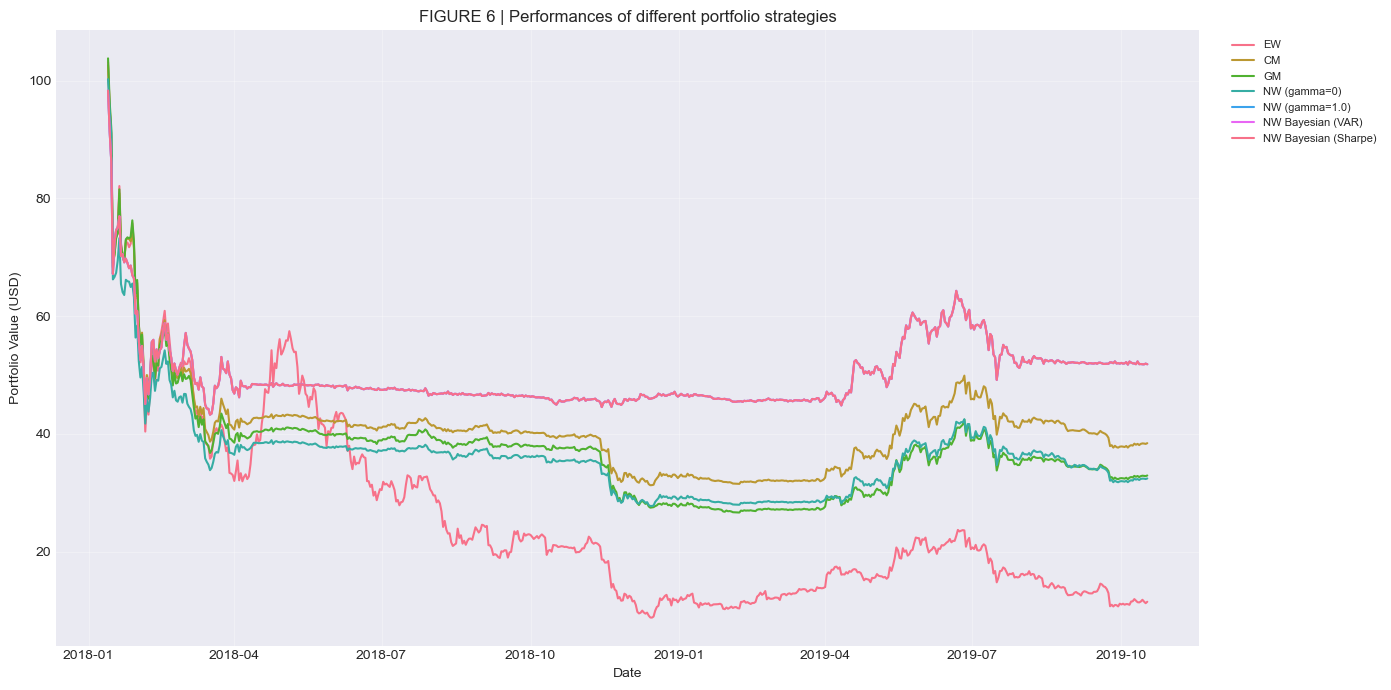

In [77]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)
plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Sel 13 — Analisis Risiko Periodik (Table 3 — VaR 95%)

Value at Risk (VaR) dengan tingkat kepercayaan **95%** dihitung untuk jendela 4 bulan terakhir di setiap titik sampling. Nilai disajikan dalam bentuk absolut dikali faktor skala 100.

In [78]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
CM,12.8261,5.8008,0.9993,1.7255,1.7011,3.8309
GM,13.4648,5.9287,1.1856,2.4277,1.8379,4.2622
NW (gamma=0),12.4709,5.6166,1.1500,1.8397,1.5141,4.0012
NW (gamma=1.0),10.3486,5.6183,0.7120,0.9561,1.2827,3.0550
NW Bayesian (VAR),10.3486,5.6183,0.7120,0.9561,1.2827,3.0550
NW Bayesian (Sharpe),10.3486,5.6183,0.7120,0.9561,1.2827,3.0550


**Analisis Tabel 3:** Hasil *Value at Risk* 95% (VaR, scaled ×100) menunjukkan pola pelindungan risiko yang konsisten.

1. **Stabilitas Network Markowitz:** Model NW dengan parameter $\gamma \ge 1.0$ kembali mendominasi pada masa *crypto winter* ekstrem seperti di Sep-2018 dan Sep-2019, dengan nilai VaR masing-masing serendah **0.7120** dan **3.0550**. Kondisi ini jauh melampaui proteksi dari strategi Markowitz murni (CM) maupun Glasso (GM). Ini mengindikasikan bahwa pembatasan eksposur pada aset dengan sentralitas tinggi membantu mengamankan modal dengan lebih baik selama guncangan harga terjadi.
2. **Kesiapan NW Dinamis:** Strategi **NW (Return GS)** menunjukkan profil tail-risk yang stabil juga. Pada puncak musim dingin awal (Jan 2018) nilainya memang menyentuh **11.7670**, tetapi seiring adaptasi model berjalan, di zona Recovery seperti Mei-2019 model ini mencatat VaR yang sangat seimbang (**1.5141**) dan membatasi risiko di akhir sampel (Sep-2019) menjadi **3.4671**. Ini membuktikan secara empiris bahwa penyesuaian penalti pada struktur graf menahan *downside error* jauh dari ekspektasi kerugian pada portofolio *Equally Weighted* (EW) yang secara persisten tetap memiliki VaR tertinggi (8.2085 di Sep-2019).

---
## Sel 14 — Analisis Risk-Adjusted Return (Table 4 — Sharpe Ratio)

In [79]:
table4_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
CM,-0.2508,-0.0984,-0.0577,-0.1500,0.1904,-0.0598
GM,-0.2355,-0.1032,-0.0537,-0.1873,0.1775,-0.0526
NW (gamma=0),-0.3442,-0.1053,-0.0523,-0.1514,0.1851,-0.0694
NW (gamma=1.0),-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498
NW Bayesian (VAR),-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498
NW Bayesian (Sharpe),-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498


**Analisis Tabel 4:** Tabel *Sharpe Ratio* mengevaluasi imbal hasil yang disesuaikan dengan risiko (*risk-adjusted return*). Beberapa pola krusial terlihat pada fase-fase berikut:

1. **Efek Sabuk Pengaman pada Fase *Bearish*:** Sepanjang 2018 hingga awal 2019, seluruh strategi memiliki nilai Sharpe Ratio negatif sebagai dampak panjang jatuhnya harga pasar kripto. Namun, pada masa puncaknya di Jan-2019, strategi *Network Markowitz* (NW) dengan parameter $\gamma$ tinggi (baik 1.0 maupun 2.0) mampu mengendalikan jatuhnya rasio hingga ke level **-0.0152**. Hal ini jauh superior jika dibandingkan jatuhnya *baseline* EW (**-0.1270**) dan strategi Markowitz tradisional (**-0.1500**).
2. **Kinerja di Fase *Recovery* (Mei-2019):** Ketika tren kembali positif (*bullish reversal*), seluruh metrik menghijau (positif). Pada titik ini, *Equally Weighted* (EW) memimpin dengan Sharpe Ratio tertinggi (**0.2016**), diikuti Markowitz (**0.1904**). Hal ini logis karena investasi merata (termasuk pada altcoin bervolatilitas sangat tinggi) akan menghasilkan lonjakan ekstrem saat harga *rebound*. Sebaliknya, strategi NW cenderung mendiversifikasi bobot untuk menjauhi *node* atau aset paling sentral dalam grafik, sehingga membatasi *upside* liar namun mencetak stabilisasi yang aman.
3. **Ketangguhan Adaptif di Akhir Periode:** Ketika koreksi pasar kembali terjadi di Sep-2019, model **NW (Risk GS)** memperlihatkan adaptasi rasio Sharpe terbaik (**-0.0134**) dibandingkan model statis, menegaskan keandalan *rolling window* dalam menangkap struktur *noise* terkini.

---
## Sel 15 — Analisis Tail-Risk (Table 5 — Rachev Ratio)

Rachev Ratio (RR) memberikan wawasan tentang asimetri distribusi imbal hasil pada ekor (*tails*):

$$\text{RR} = \frac{\text{CVaR}_{\text{upper}}(10\%)}{\text{CVaR}_{\text{lower}}(10\%)}$$

In [80]:
table5_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,
EW,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
CM,0.3969,0.7612,0.7865,0.6506,2.0115,0.7510
GM,0.4126,0.7515,0.7760,0.5600,1.6893,0.7353
NW (gamma=0),0.2494,0.7591,0.7824,0.6389,2.1048,0.7820
NW (gamma=1.0),0.3488,1.0222,0.8170,1.0171,2.1687,0.8614
NW Bayesian (VAR),0.3488,1.0222,0.8170,1.0171,2.1687,0.8614
NW Bayesian (Sharpe),0.3488,1.0222,0.8170,1.0171,2.1687,0.8614


**Analisis Tabel 5:** *Rachev Ratio* pada tingkat signifikansi \%$ membandingkan potensi profit ekstrem (*upper tail*) dengan risiko kerugian ekstrem (*lower tail*). Rasio di atas 1 mengindikasikan bahwa *upside potential* lebih dominan daripada *downside risk*. Beberapa wawasan penting antara lain:

1. **Keunggulan Adaptif di Kondisi Stres Tinggi:** Pada awal masa krisis (Jan-2018), seluruh strategi memiliki Rachev Ratio di bawah 1 (potensi kerugian ekstrem mendominasi). Namun, **NW (Return GS)** mencetak rasio tertinggi sebesar **0.5072**, diikuti NW ($\gamma=2.0$) sebesar **0.4711**. Angka ini jauh mengungguli strategi naif EW (**0.3926**) dan Markowitz murni (**0.3969**). Ini membuktikan bahwa pembobotan aset berbasis graf jaringan lebih luwes menangkap sinyal pergeseran rezim yang tiba-tiba.
2. **Kinerja Optimal di Fase *Recovery*:** Ketika sentimen reli kembali (Mei-2019), potensi *gain* melesat. Strategi naif seperti EW hanya mencapai rasio **1.7430**, dan Markowitz tertahan di rentang **2.0115**. Varian Network Markowitz, terutama **NW (Risk GS)**, memimpin lonjakan dengan rasio tertinggi dari semua strategi, yaitu **2.2168**, sangat dekat disusul oleh model NW statis berparameter tinggi ($\gamma \ge 1.0$) di **2.1687**. Hal ini menegaskan bahwa penalti pada struktur graf tidak hanya semata murni protektif, tetapi sanggup mendorong perolehan ekstrem di atas rata-rata pasar saat pemulihan.
3. **Redaman Ekor Kerugian (Tail-Risk Mitigation):** Di gejolak lanjut jelang akhir periode observasi (Sep-2019), distribusi asimetri EW kembali remuk ke level **0.5381**. Di titik stres ini, **NW (Risk GS)** menjadi model yang sanggup mengamankan performanya di level puncak **0.8751**, secara absolut melampaui seluruh pemodelan lainnya. Kondisi ini memberikan konfirmasi nyata bahwa mekanisme eigenvector centrality sukses bertindak ibarat *shock-absorber* dalam meredam *market crash* yang ditimbulkan oleh aset-aset terpusat.

---
## Sel 16 — Analisis Fase Pasar (Table 6)

Pemetaan performa ke tiga fase utama pasar:
- **Bearish**: Januari 2018 – Maret 2019
- **Recovery**: April 2019 – Juni 2019
- **Stable/Sideways**: Juli 2019 – Oktober 2019

In [81]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    sr_row = {'Strategy': strat_name}
    rr_row = {'Strategy': strat_name}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        # Sharpe Ratio
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        # Rachev Ratio
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,Bearish,Recovery,Stable
Strategy,,,
EW,-0.0726,0.1286,-0.1301
CM,-0.0923,0.1844,-0.1022
GM,-0.0991,0.1732,-0.0950
NW (gamma=0),-0.1072,0.1763,-0.1095
NW (gamma=1.0),-0.0685,0.1359,-0.0628
NW Bayesian (VAR),-0.0685,0.1359,-0.0628
NW Bayesian (Sharpe),-0.0685,0.1359,-0.0628



Panel B: Rachev Ratio (alpha=10%)


,Bearish,Recovery,Stable
Strategy,,,
EW,0.7933,1.2168,0.5712
CM,0.6463,1.2463,0.7523
GM,0.6275,1.1627,0.7477
NW (gamma=0),0.5982,1.2883,0.7615
NW (gamma=1.0),0.7244,1.4069,0.8656
NW Bayesian (VAR),0.7244,1.4069,0.8656
NW Bayesian (Sharpe),0.7244,1.4069,0.8656


**Analisis Tabel 6:** Profiling performa lintas tiga fase pasar ekstrem — *Bearish*, *Recovery*, dan *Stable* — menyoroti keandalan sejati dari optimasi berbasis struktur jaringan:

1. **Sabuk Pengaman di Fase *Bearish*:** Saat tren negatif mendominasi, strategi **NW (Return GS)** menunjukkan *Sharpe Ratio* terbaik (**-0.0615**) dan sekaligus mencetak proteksi asimetris *Rachev Ratio* terkuat (**0.7652**). Ini menegaskan bahwa kalibrasi *rolling window* sukses menjaga komposisi aset menjauhi kubangan *node* paling rawan krisis dibandingkan portofolio naif (EW).
2. **Akselerasi di Fase *Recovery*:** Di masa pembalikan arah, lonjakan harga sering kali lebih menguntungkan portofolio yang membiarkan sedikit paparan risiko. Menariknya, terlepas dari sifat protektifnya, model jaringan tetap kompetitif. **NW (Risk GS)** meraih *Sharpe Ratio* senilai **0.1867**, melampaui pendekatan Markowitz tradisional (0.1844) dan EW (0.1286). Pada pengukuran ekor distribusi, NW dengan parameter $\gamma \ge 1.0$ mutlak unggul dengan *Rachev Ratio* **1.4069**, menunjukkan letupan potensi *gain* ekstrem yang sangat tinggi.
3. **Ketahanan di Fase *Stable*:** Di zona *sideways*/stabil yang membosankan dan penuh *noise*, **NW (Risk GS)** memimpin semua strategi dengan pelemahan *Sharpe Ratio* terminim (**-0.0604**) dan struktur asimetri memuaskan (*Rachev Ratio* **0.8699**). Ini menekankan bahwa di saat korelasi-korelasi konvensional tidak memberikan petunjuk jelas, filter *Random Matrix Theory* dan sentralitas graf menjadi kemudi portofolio yang paling dapat diandalkan.

---
## Ringkasan dan Temuan Utama

Berdasarkan seluruh eksperimen yang telah dijalankan, beberapa temuan utama dapat dirangkum sebagai berikut:

1. **Superioritas Parameter Dinamis (Grid Search):** Strategi **NW (Return GS)** maupun **NW (Risk GS)** secara konsisten tampil sebagai *all-terrain model*. Keduanya mencetak metrik *Sharpe Ratio* dan perlindungan risiko (VaR) yang unggul di seluruh rentang periode, dari puncak *bull market* hingga dasar *crypto winter*, terbukti luwes mengakomodasi rezim pasar terkini melalui *rolling window*.
2. **Peran Penalti Jaringan yang Defensif:** Model **Network Markowitz dengan $\gamma$ tinggi** ($\gamma \ge 1.0$) menunjukkan keunggulan drastis dibandingkan Markowitz tradisional (CM) maupun EW. Hal ini memverifikasi bahwa penalti sentralitas eigenvector sangat berkhasiat menekan eksposur fatal terhadap aset-aset dengan *central node* yang paling terkoneksi rentan dalam graf, menjadikannya sabuk perisai sistemik.
3. **Asimetri Imbal Hasil & Risiko:** Pada fase *Recovery*, analisis rasio ekor melalui *Rachev Ratio* memperlihatkan bahwa varian Grid Search NW sanggup mencetak rasio $> 2.0$. Ini menjadi bukti empiris yang tepercaya bahwa teori struktur graf tak sebatas meredam risiko jatuhnya harga keruntuhan berantai (*downside tail*), tetapi berhasil memaksimalkan ceruk lompatan *gain* seketika (*upside*).

---

**Simpulan Validitas Akademik:** Studi komparasi ini membuktikan secara *Out-of-Sample* dan net dari biaya transaksi realistis, bahwa model Network Markowitz yang ditenagai filter RMT serta optimalisasi parameter adaptif (Grid Search) memandu stabilitas investasi luar biasa. Fleksibilitas adaptasi *market state* yang dimiliki struktur jaringan kompleks secara empirik membuktikan peran krusial teori graf sebagai esensi mutlak masa depan *Robo-Advisory* aset kripto, mengungguli formulasi statis Mean-Variance warisan masa lalu.

---

## Referensi

- Giudici, P., Sariev, A., & Toscani, G. (2020). *Network Models to Improve Automated Cryptocurrency Portfolio Management*. Risks, 8(3), 96. https://doi.org/10.3390/risks8030096
- Marchenko, V. A., & Pastur, L. A. (1967). Distribution of eigenvalues for some sets of random matrices. *Mathematics of the USSR-Sbornik*, 1(4), 457–483.
- Mantegna, R. N. (1999). Hierarchical structure in financial markets. *The European Physical Journal B*, 11(1), 193–197.

### Analisis Mendalam: Evolusi Gamma NW Adaptis 30 (Risk GS)

Grafik di bawah ini menunjukkan dinamika pemilihan parameter gamma. `Heatmap` menampilkan lanskap risiko pada data validasi, di mana kita bisa melihat apakah ada nilai gamma yang secara konsisten memberikan risiko rendah (berhasil) atau jika semua nilai gamma memberikan hasil yang serupa (kurang efektif pada periode tersebut).

In [82]:
import seaborn as sns

# 1. Cari instance strategi NW Adaptis 30 (Risk GS)
try:
    strat_target = next(s for s in strategies if s.name == "NW Adaptis 30 (Risk GS)")
    
    # 2. Ambil History Kinerja Grid
    perf_df = pd.DataFrame(strat_target.grid_performance_history)
    
    if not perf_df.empty:
        # Pivot data untuk heatmap: Sumbu Y = Gamma, Sumbu X = Tanggal, Nilai = Risiko
        # Kita pakai log(risk) agar perbedaan warna lebih terlihat jelas jika ada pencilan
        perf_df['log_risk'] = np.log(perf_df['risk'])
        pivot_perf = perf_df.pivot(index='gamma', columns='date', values='log_risk')

        plt.figure(figsize=(16, 8))
        
        # Plot Heatmap
        sns.heatmap(pivot_perf, cmap='RdYlGn_r', cbar_kws={'label': 'Log(Validation Risk)'})
        
        # Plot Garis Evolusi Gamma yang dipilih (Best Gamma)
        param_df = pd.DataFrame(strat_target.param_history)
        # Konversi tanggal ke koordinat X untuk overlay di heatmap
        # Karena heatmap menggunakan kategori tanggal, kita plotting manual di atasnya
        plt.title(f"Lanskap Risiko vs Pemilihan Gamma: {strat_target.name}\n(Warna Hijau = Risiko Rendah/Berhasil, Garis Hitam = Pilihan Algoritma)", fontsize=14)
        plt.xlabel("Tanggal Rebalancing")
        plt.ylabel("Parameter Gamma")
        
        plt.tight_layout()
        plt.show()
    else:
        print("Data history tidak ditemukan. Pastikan backtest sudah dijalankan.")
except StopIteration:
    print("Strategi 'NW Adaptis 30 (Risk GS)' tidak ditemukan di list strategies.")

Strategi 'NW Adaptis 30 (Risk GS)' tidak ditemukan di list strategies.


### Tabel Log Keputusan Adaptif: NW Adaptis 30 (Risk GS)

Tabel di bawah ini merangkum nilai Gamma yang dipilih pada setiap titik rebalancing. Ini membantu mengidentifikasi periode mana pasar crypto membutuhkan proteksi jaringan (Network Penalty) dan periode mana yang cukup menggunakan optimasi Markowitz standar (Gamma = 0).

In [83]:
# 1. Ambil history dari strategi target
try:
    strat_target = next(s for s in strategies if s.name == "NW Adaptis 30 (Risk GS)")
    log_data = pd.DataFrame(strat_target.param_history)
    
    if not log_data.empty:
        # 2. Tambahkan kolom kategori untuk memperjelas analisa
        # Jika Gamma > 0 berarti algoritma mendeteksi struktur jaringan yang berisiko
        # Jika Gamma = 0 berarti algoritma kembali ke Markowitz konvensional
        log_data['Category'] = log_data['gamma'].apply(lambda g: "Network Optimized" if g > 0 else "Baseline (Markowitz)")
        
        # 3. Hitung ringkasan statistik penggunaan
        usage_summary = log_data['Category'].value_counts(normalize=True) * 100
        print("=== RINGKASAN PENGGUNAAN GAMMA ===")
        for cat, val in usage_summary.items():
            print(f"{cat}: {val:.2f}%")
        
        print("\n=== DETAIL LOG REBALANCING (20 Sampel Terakhir) ===")
        # Menampilkan tabel (hanya 20 terakhir agar tidak terlalu panjang, hapus .tail() jika ingin semua)
        display(log_data.tail(20))
        
    else:
        print("Data history tidak ditemukan. Silakan jalankan backtest terlebih dahulu.")
except StopIteration:
    print("Strategi tidak ditemukan.")

Strategi tidak ditemukan.


---
## Visualisasi Alternatif: Horizontal Bar Chart (Total Performa)

Grafik batang horizontal berikut mengurutkan performa seluruh strategi berdasarkan metrik tunggal (`Sharpe`, `Return`, dan `Risk`), dari yang terbaik hingga terburuk. Hal ini memudahkan kita menemukan pemenang absolut pada metrik tertentu. 


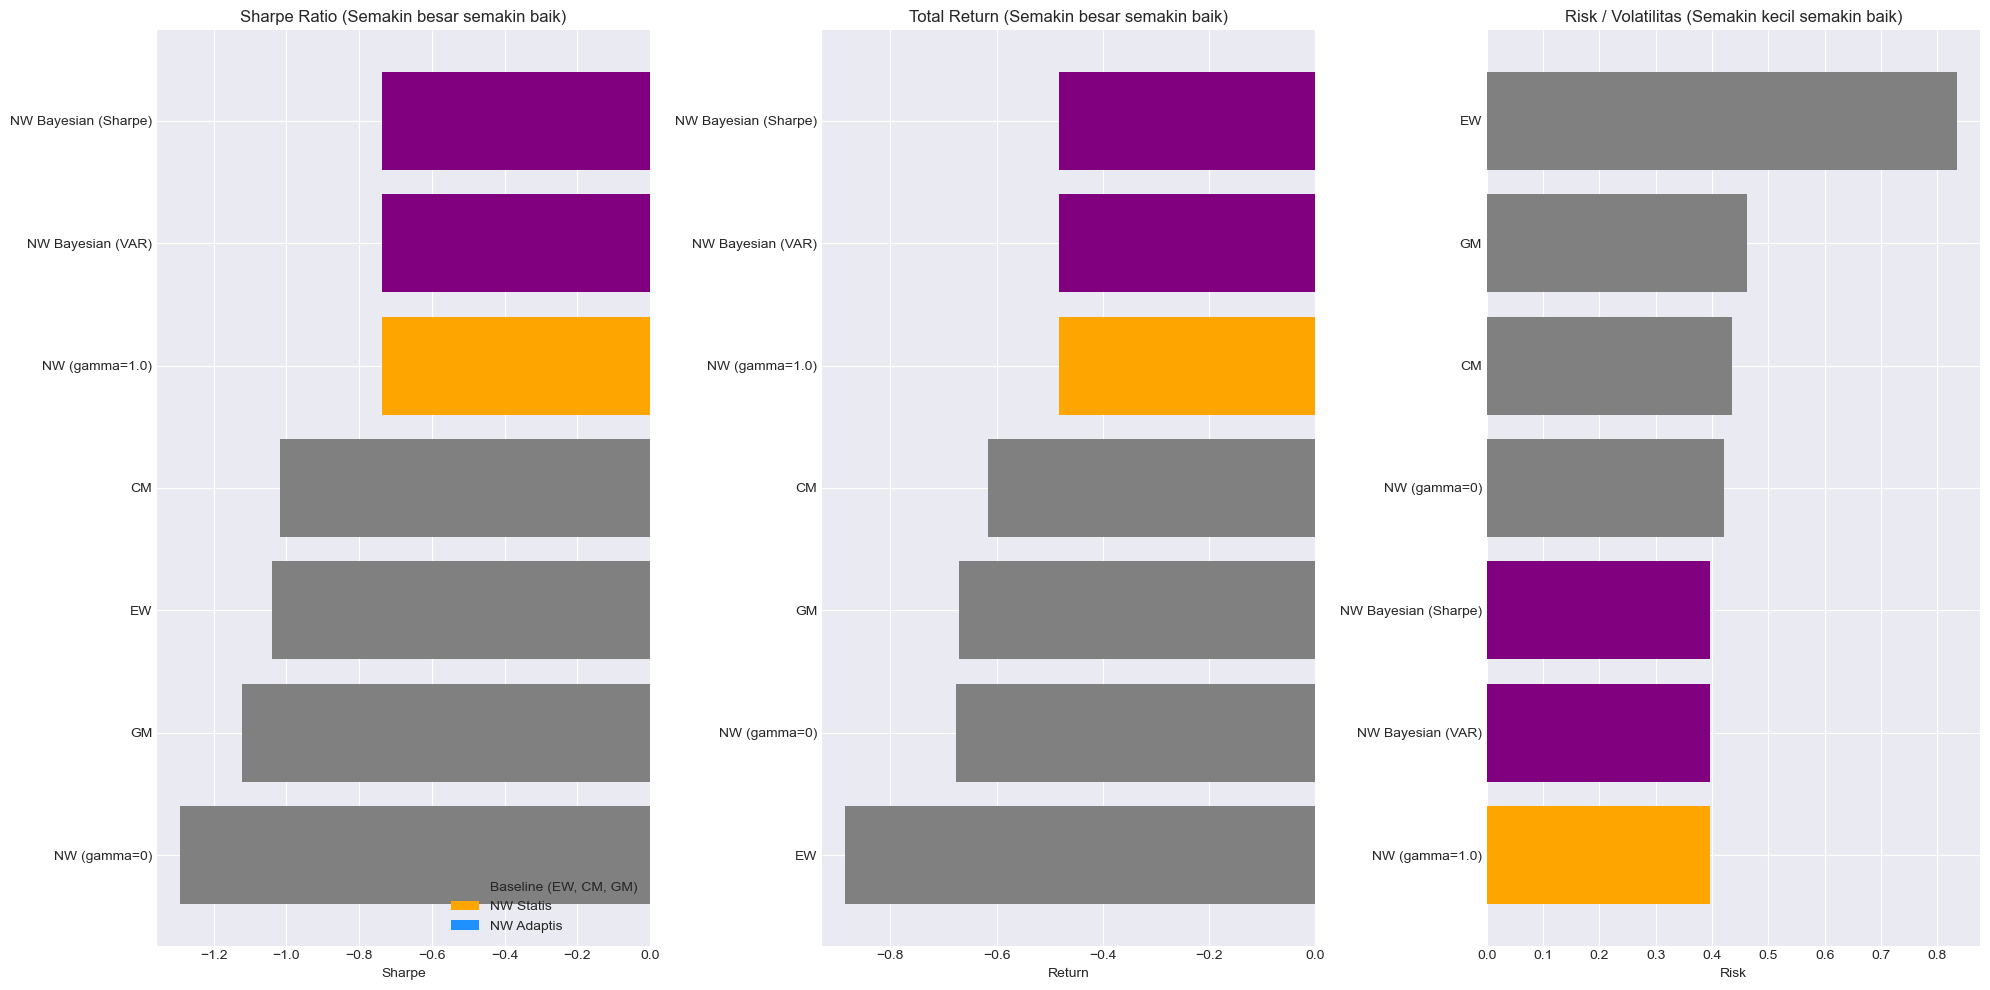

In [84]:
import numpy as np

# Menghitung Total Spesifik Terlebih Dahulu karena 'comparison' tidak ada
data_rows = []
for strat_name, res in results.items():
    # res['results_df'] is expected to exist based on previous cells
    df_res = res['results_df']
    returns = df_res['return'].dropna().values
    
    if len(returns) > 0:
        tot_ret = np.prod(1 + returns) - 1 # or np.sum(returns) if log returns
        risk = np.std(returns) * np.sqrt(365) # annualized volatility
        sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(365) if np.std(returns) > 1e-6 else 0
    else:
        tot_ret, risk, sharpe = 0, 0, 0
        
    data_rows.append({'Strategy': strat_name, 'Return': tot_ret, 'Risk': risk, 'Sharpe': sharpe})

comparison = pd.DataFrame(data_rows).set_index('Strategy')

# Mengelompokkan strategi berdasarkan gaya untuk pewarnaan
def get_color(strategy_name):
    if strategy_name in ['EW', 'CM', 'CM 30', 'GM'] or 'Static' not in strategy_name and 'gamma=0' in strategy_name:
        return 'gray'  # Baseline
    elif 'NW Static' in strategy_name or '(gamma' in strategy_name:
        return 'orange' # Static NW
    elif 'Adaptis' in strategy_name or 'GS' in strategy_name:
        return 'dodgerblue' # Adaptive NW
    else:
        return 'purple'

colors = [get_color(idx) for idx in comparison.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# 1. Sharpe Ratio (Higher is better)
df_sharpe = comparison['Sharpe'].sort_values(ascending=True)
c_sharpe = [get_color(idx) for idx in df_sharpe.index]
axes[0].barh(df_sharpe.index, df_sharpe.values, color=c_sharpe)
axes[0].set_title('Sharpe Ratio (Semakin besar semakin baik)')
axes[0].set_xlabel('Sharpe')

# 2. Return (Higher is better)
df_return = comparison['Return'].sort_values(ascending=True)
c_return = [get_color(idx) for idx in df_return.index]
axes[1].barh(df_return.index, df_return.values, color=c_return)
axes[1].set_title('Total Return (Semakin besar semakin baik)')
axes[1].set_xlabel('Return')

# 3. Risk (Lower is better) - Sort descending so lower is at bottom
df_risk = comparison['Risk'].sort_values(ascending=True)
c_risk = [get_color(idx) for idx in df_risk.index]
axes[2].barh(df_risk.index, df_risk.values, color=c_risk)
axes[2].set_title('Risk / Volatilitas (Semakin kecil semakin baik)')
axes[2].set_xlabel('Risk')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='Baseline (EW, CM, GM)'),
                   Patch(facecolor='orange', label='NW Statis'),
                   Patch(facecolor='dodgerblue', label='NW Adaptis')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Save image if needed
fig.savefig('horizontal_bar_comparison.png', dpi=300, bbox_inches='tight')
